In [1]:
import json
import pandas as pd
import numpy as np
import scanpy as sc

import seaborn as sns
import matplotlib.pyplot as plt


## merge raw counts of two cell types

In [ ]:
adata_hek293ft_geo = sc.read_h5ad('raw/GSE269596_CPA_HEK293FT.h5ad')
adata_hek293ft_geo.obs['cellline'] = 'HEK293FT'
adata_k562_geo = sc.read_h5ad('raw/GSE269596_CPA_K562.h5ad')
adata_k562_geo.obs['cellline'] = 'K562'
adata_geo = sc.concat([adata_hek293ft_geo, adata_k562_geo], axis=0, join='inner')
adata_geo.obs_names_make_unique()
adata_geo.write('raw/CPA_merged_geo.h5ad')

## load raw data and filter genes not in prior knowledge

In [2]:
radata_geo = sc.read_h5ad('raw/CPA_merged_geo.h5ad')
print(radata_geo)
radata_geo.obs.head().T

AnnData object with n_obs × n_vars = 74312 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'target_gene', 'mixscape_class', 'mixscape_class.global', 'cellline'


,R1-L1_AAACCCAAGCCTAACT,R1-L1_AAACCCAAGGGTTAAT,R1-L1_AAACCCACAAGTCATC,R1-L1_AAACCCACACAAATGA,R1-L1_AAACCCACATGACACT
nCount_RNA,3242.0,49831.0,39207.0,20777.0,7091.0
nFeature_RNA,1273,7550,6431,4643,2646
nCount_GUIDE,76.0,1394.0,811.0,546.0,562.0
nFeature_GUIDE,24,14,8,14,17
nCount_polyA,2907.0,45476.0,34698.0,18322.0,6589.0
nFeature_polyA,1364,14819,11866,7441,3652
nCount_HTO,319.0,1861.0,696.0,882.0,233.0
nFeature_HTO,8,8,8,8,8
replicate,R1,R1,R1,R1,R1
lane,L1,L1,L1,L1,L1


In [3]:
padata_geo = radata_geo
padata_geo.obs = radata_geo.obs.rename(columns={
    'target_gene': 'perturbation'
})
padata_geo.obs['perturbation'] = padata_geo.obs['perturbation'].map(lambda x: 'control' if x.startswith('NT') else x)
padata_geo

AnnData object with n_obs × n_vars = 74312 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline'

## preprocessing

The datasets from zenodo are very inconsistent with data collected from GEO.

- only about a half ad_zenodo.obs_names is in ad_geo.obs_names.
- only about 3,000 genes are in ad_zenodo.var_names while 36,000 in ad_geo.var_names.

Therefore, just leave alone ad_zenodo totally and apply ad_geo.



In [5]:
padata = padata_geo.copy()
padata.X = padata.X.astype(np.float32)
sc.pp.filter_cells(padata, min_genes=200)
sc.pp.filter_genes(padata, min_cells=50)

filtered out 45 cells that have less than 200 genes expressed
filtered out 14216 genes that are detected in less than 50 cells


In [6]:
selected_pert_df = padata.obs.groupby(
    ['perturbation', 'cellline'], observed=True
).size().reset_index(name='count')
selected_pert_df['count'].min()

64

In [7]:
selected_pert_df = padata.obs[['perturbation', 'cellline']].drop_duplicates().groupby(
    'perturbation', observed=True
).size().reset_index(name='count')
selected_perts = selected_pert_df.query('count > 1')['perturbation'].values
padata = padata[padata.obs['perturbation'].isin(selected_perts)].copy()
print(padata_geo, "\n-->\n", padata)

AnnData object with n_obs × n_vars = 74312 × 36601
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline' 
-->
 AnnData object with n_obs × n_vars = 73080 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes'
    var: 'n_cells'


In [8]:
padata.layers['raw'] = padata.X.copy()
sc.pp.normalize_total(padata, target_sum=1e4)
sc.pp.log1p(padata)
sc.pp.highly_variable_genes(
    padata, n_top_genes=5000, 
    subset=False, flavor='seurat',
)
print(padata.shape)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
(73080, 22385)


In [11]:
padata

AnnData object with n_obs × n_vars = 73080 × 22385
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'log1p', 'hvg'
    layers: 'raw'

In [12]:
padata.write_h5ad('preprocessed.h5ad')

## split dataset

In [ ]:
adata = sc.read("preprocessed.h5ad", backed='r')

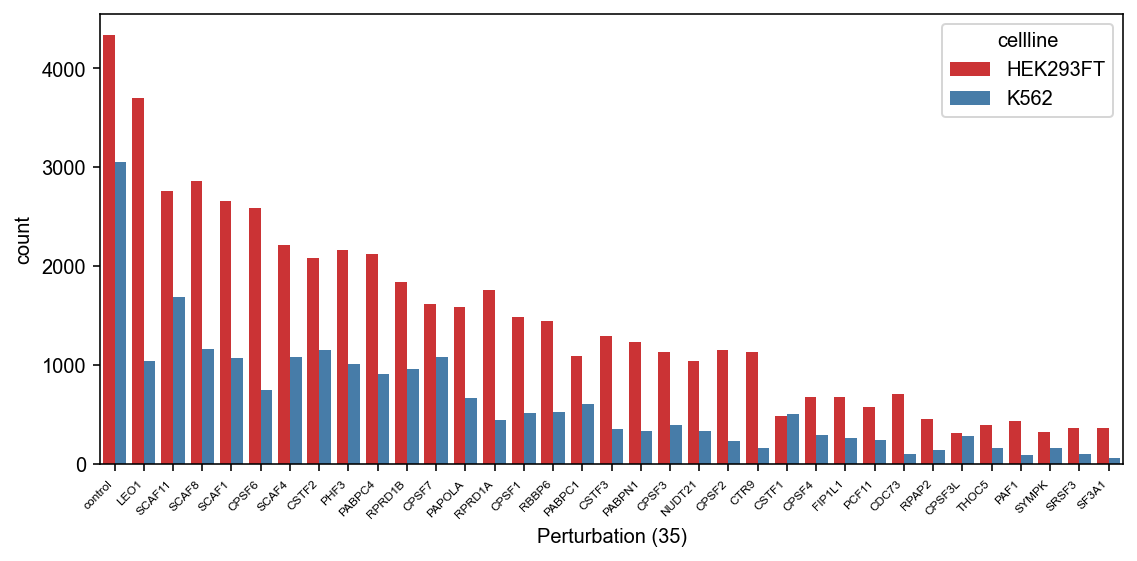

In [ ]:
df = adata.obs.groupby(['cellline', 'perturbation'], observed=True).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df, x='perturbation', y='count', hue='cellline',
    order=df.groupby('perturbation', observed=True)['count'].sum().sort_values(ascending=False).index,
    palette='Set1',
    ax=ax
)
# rotate the x ticks
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.xlabel(f'Perturbation ({df["perturbation"].nunique()})')
plt.tight_layout()
plt.show()

train on one cell type and test on the other

In [ ]:
np.random.seed(42)
split_df = (
    adata
    .obs[['cellline']]
    .copy()
    .reset_index(names='cell')
    .rename(columns={'cellline': 'subsplit'})
)
split_df['presplit'] = np.random.choice(
    ['train', 'val', 'test'], 
    size=split_df.shape[0], 
    p=[0.7, 0.1, 0.2], 
    replace=True
)


In [ ]:
# train on K562 and test on HEK293FT
split_df['split'] = split_df[['subsplit', 'presplit']].apply(
    lambda x: x['presplit'] if x['subsplit'] == 'K562' else 'test', axis=1
)
split_df[['cell', 'split', 'subsplit']].to_csv('split_trainonk562.csv', index=False)
pd.read_csv('split_trainonk562.csv').groupby(['split', 'subsplit']).size()

split  subsplit
test   HEK293FT    51092
       K562         4380
train  K562        15348
val    K562         2260
dtype: int64

In [ ]:
# train on Resting and test on Re-stimulated=
split_df['split'] = split_df[['subsplit', 'presplit']].apply(
    lambda x: x['presplit'] if x['subsplit'] == 'HEK293FT' else 'test', axis=1
)
split_df[['cell', 'split', 'subsplit']].to_csv('split_trainonhek293ft.csv', index=False)
pd.read_csv('split_trainonhek293ft.csv').groupby(['split', 'subsplit']).size()

split  subsplit
test   HEK293FT    10157
       K562        21988
train  HEK293FT    35909
val    HEK293FT     5026
dtype: int64

## shuffle partial labels for creating noisy data

In [33]:
adata = sc.read_h5ad('preprocessed.h5ad')

In [34]:
adata.obs['perturbation_true'] = adata.obs['perturbation'].copy()

In [35]:
shuffle_rate = 0.1
np.random.seed(0) # using 0 since 42 surprisingly leads to no shuffling for HEK293FT test set!
shuffle_mask = (np.random.rand(len(adata)) < shuffle_rate) & (adata.obs['perturbation_true'] != 'control')
shuffle_labels = adata.obs['perturbation_true'].copy()
shuffle_labels[shuffle_mask] = np.random.permutation(shuffle_labels[shuffle_mask])
adata.obs['perturbation'] = shuffle_labels

In [36]:
adata.write_h5ad('preprocessed_noisy.h5ad')

check simulated data

In [8]:
adata = sc.read_h5ad('preprocessed_noisy.h5ad')
split_df = pd.read_csv('split_trainonhek293ft.csv')

In [9]:
split_df.groupby(['split', 'subsplit']).size()

split  subsplit
test   HEK293FT    10157
       K562        21988
train  HEK293FT    35909
val    HEK293FT     5026
dtype: int64

<Axes: xlabel='perturbation_true', ylabel='perturbation'>

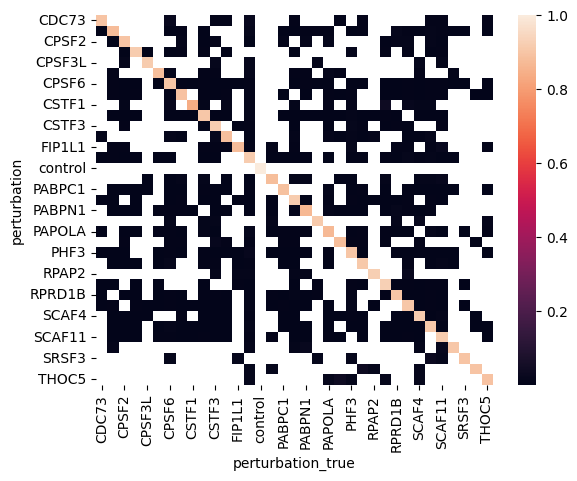

In [39]:
sns.heatmap(adata.obs.loc[
    split_df.query('split == "test" and subsplit == "HEK293FT"').cell.values, 
    ['perturbation', 'perturbation_true']
].value_counts().unstack().transform(lambda x: x / x.sum(), axis=1))

<Axes: xlabel='perturbation_true', ylabel='perturbation'>

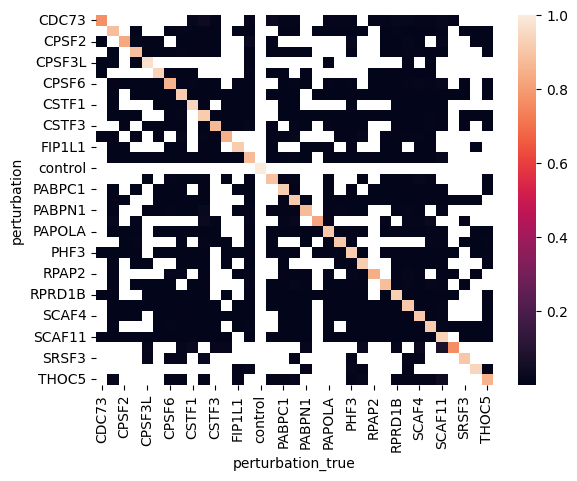

In [ ]:
sns.heatmap(adata.obs.loc[
    split_df.query('split == "test" and subsplit == "K562"').cell.values, 
    ['perturbation', 'perturbation_true']
].value_counts().unstack().transform(lambda x: x / x.sum(), axis=1))

## remove perturbed genes from feature list

In [ ]:
ad = sc.read_h5ad('preprocessed.h5ad')
pertgenes = ad.obs['perturbation'].unique()
pertgenes = [g for g in pertgenes if (g != 'control') and (g in ad.var_names)]
ad_reduced = ad[:, ~ad.var_names.isin(pertgenes)].copy()
pertexpr_df = ad[:, pertgenes].copy().to_df()
ad_reduced.obsm['pertexpr'] = pertexpr_df
ad_reduced.write_h5ad('preprocessed_reduced.h5ad')



In [ ]:
ad_reduced

AnnData object with n_obs × n_vars = 73080 × 22352
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_GUIDE', 'nFeature_GUIDE', 'nCount_polyA', 'nFeature_polyA', 'nCount_HTO', 'nFeature_HTO', 'replicate', 'lane', 'MULTI_ID', 'MULTI_classification', 'HTO_classification', 'guide', 'perturbation', 'mixscape_class', 'mixscape_class.global', 'cellline', 'n_genes', 'replicate+lane', 'leiden', 'cluster'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'cellline_colors', 'cluster_colors', 'hvg', 'lane_colors', 'leiden', 'log1p', 'neighbors', 'pca', 'perturbation_colors', 'replicate+lane_colors', 'replicate_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'pertexpr'
    varm: 'PCs'
    layers: 'raw'
    obsp: 'connectivities', 'distances'

In [ ]:
ad.shape[1] - ad_reduced.shape[1]

33

## training only on one batch and testing on both batches and cell types

In [2]:
obs_df = sc.read_h5ad('preprocessed.h5ad', backed='r').obs.copy()

In [3]:
obs_df

,nCount_RNA,nFeature_RNA,nCount_GUIDE,nFeature_GUIDE,nCount_polyA,nFeature_polyA,nCount_HTO,nFeature_HTO,replicate,lane,...,HTO_classification,guide,perturbation,mixscape_class,mixscape_class.global,cellline,n_genes,replicate+lane,leiden,cluster
R1-L1_AAACCCAAGCCTAACT,3242.0,1273,76.0,24,2907.0,1364,319.0,8,R1,L1,...,HTO-07-TGTCTTTCCTGCCAG,SCAF4-I4,SCAF4,SCAF4 KD,KD,HEK293FT,1273,R1+L1,10,C2
R1-L1_AAACCCAAGGGTTAAT,49831.0,7550,1394.0,14,45476.0,14819,1861.0,8,R1,L1,...,HTO-06-GGTTGCCAGATGTCA,LEO1-I2,LEO1,LEO1 KD,KD,HEK293FT,7550,R1+L1,3,C2
R1-L1_AAACCCACAAGTCATC,39207.0,6431,811.0,8,34698.0,11866,696.0,8,R1,L1,...,HTO-08-CTCCTCTGCAATTAC,PAPOLA-I4,PAPOLA,PAPOLA KD,KD,HEK293FT,6431,R1+L1,3,C2
R1-L1_AAACCCACACAAATGA,20777.0,4643,546.0,14,18322.0,7441,882.0,8,R1,L1,...,HTO-06-GGTTGCCAGATGTCA,CSTF3-I3,CSTF3,CSTF3 KD,KD,HEK293FT,4643,R1+L1,4,C2
R1-L1_AAACCCACATGACACT,7091.0,2646,562.0,17,6589.0,3652,233.0,8,R1,L1,...,HTO-07-TGTCTTTCCTGCCAG,CPSF3-I1,CPSF3,CPSF3 KD,KD,HEK293FT,2646,R1+L1,4,C2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R2-L2_TTTGTTGAGCGTACAG,9880.0,2729,192.0,3,7554.0,3115,476.0,8,R2,L2,...,HTO-29-TATCACATCGGT,SCAF11-I2,SCAF11,SCAF11 KD,KD,K562,2729,R2+L2,7,C1
R2-L2_TTTGTTGAGTGGTGGT,13861.0,3375,160.0,7,11273.0,4164,350.0,8,R2,L2,...,HTO-52-GACGTACCGGAT,NT-I2,control,NT,NT,K562,3375,R2+L2,7,C1
R2-L2_TTTGTTGTCAAACGTC,3270.0,1591,277.0,16,2931.0,1876,529.0,8,R2,L2,...,HTO-51-CGCCTATATACT,RPAP2-I3,RPAP2,RPAP2 KD,KD,K562,1591,R2+L2,2,C1
R2-L2_TTTGTTGTCAGTCAGT,10777.0,2863,319.0,10,8552.0,3428,613.0,8,R2,L2,...,HTO-27-GTGTGACGTATT,CSTF2-I4,CSTF2,CSTF2 KD,KD,K562,2863,R2+L2,7,C1


In [12]:
split_df = pd.read_csv('split_trainonhek293ft.csv')
split_df['subsplit'] = split_df['subsplit'].values.astype(str) + '_' + obs_df.loc[split_df['cell'], 'replicate'].values.astype(str)
split_df.groupby(['split', 'subsplit']).size()

split  subsplit   
test   HEK293FT_R1     2544
       HEK293FT_R2     7613
       K562_R1        13432
       K562_R2         8556
train  HEK293FT_R1     9092
       HEK293FT_R2    26817
val    HEK293FT_R1     1218
       HEK293FT_R2     3808
dtype: int64

In [13]:
split_df['split'] = split_df[['split', 'subsplit']].apply(lambda x: 'test' if x['subsplit'] == 'HEK293FT_R1' else x['split'], axis=1)
split_df['subsplit'] = split_df[['split', 'subsplit']].apply(lambda x: x['subsplit'].split('_')[0] if x['split'] == 'test' and not x['subsplit'].startswith('HEK293FT') else x['subsplit'], axis=1)
split_df.groupby(['split', 'subsplit']).size()

split  subsplit   
test   HEK293FT_R1    12854
       HEK293FT_R2     7613
       K562           21988
train  HEK293FT_R2    26817
val    HEK293FT_R2     3808
dtype: int64

In [14]:
split_df.to_csv('split_trainonhek293ft_r2.csv', index=False)

In [15]:
split_df = pd.read_csv('split_trainonk562.csv')
split_df['subsplit'] = split_df['subsplit'].values.astype(str) + '_' + obs_df.loc[split_df['cell'], 'replicate'].values.astype(str)
split_df.groupby(['split', 'subsplit']).size()

split  subsplit   
test   HEK293FT_R1    12854
       HEK293FT_R2    38238
       K562_R1         2689
       K562_R2         1691
train  K562_R1         9374
       K562_R2         5974
val    K562_R1         1369
       K562_R2          891
dtype: int64

In [16]:
split_df['split'] = split_df[['split', 'subsplit']].apply(lambda x: 'test' if x['subsplit'] == 'K562_R2' else x['split'], axis=1)
split_df['subsplit'] = split_df[['split', 'subsplit']].apply(lambda x: x['subsplit'].split('_')[0] if x['split'] == 'test' and not x['subsplit'].startswith('K562') else x['subsplit'], axis=1)
split_df.groupby(['split', 'subsplit']).size()

split  subsplit
test   HEK293FT    51092
       K562_R1      2689
       K562_R2      8556
train  K562_R1      9374
val    K562_R1      1369
dtype: int64

In [17]:
split_df.to_csv('split_trainonk562_r1.csv', index=False)